In [ ]:
import numpy as np
from bigraph_viz import plot_bigraph
from process_bigraph import Process, Composite, allocate_core, gather_emitter_results

In [ ]:
# make a new types system "core"
core = allocate_core()

# subcellular

In [190]:
mitosis_phase = {
    'G2': {},
    'M': {},
    'G1': {},
    'S': {},
}
nonproliferative = {
    'G1': {},
    'meioticS': {},
    'prophase of meiosis I': {},
}

cell_state_definition = {
    'germ': {
        'radius': 1.0
    },
    'mitosis': {
        'radius': 1.0
    },
    'meioticS': {
        'radius': 1.0
    },
    'prophase of meiosis I': {
        'radius': 1.0
    },
    'oogenic': {
        'radius': 1.0
    },
    'spermatogenic': {
        'radius': 1.0
    },
}

# class MolecularProgram(Process):

def radius_to_volume(radius):
    return 4/3 * np.pi * radius**3


class Cycle(Process):
    config_schema = {
        'G1duration': 'float',
        'G2duration': 'float',
        'Sduration': 'float',
        'Mduration': 'float',
        # 'G1duration': {'_type': 'float', '_default': 10.0},
        # 'G2duration': {'_type': 'float', '_default': 10.0},
        # 'Sduration': {'_type': 'float', '_default': 10.0},
        # 'Mduration': {'_type': 'float', '_default': 10.0},
    }

    def initialize(self, config):
        pass

    def inputs(self):
        return {
            'molecules': {
                'GLP-1': 'enum[unbound,bound,absent]',
                'LAG-1': 'enum[active,inactive]',
                'GLD-1': 'enum[active,inactive]',
                'GLD-2': 'enum[active,inactive]',
            },
            'DTC distance': 'float',
            'time in state': 'float',
            'age': 'float',
            'state': 'enum[mitosis,nonproliferative,precursor,ooFate,spFate,oocyte,sperm]',
            'phase': 'enum[G2,M,G1,S,MeioticS,prophase]',
            'sex': 'enum[precursor,ooFate,spFate,oocyte,sperm]',
            'volume': 'float',
            'radius': 'float',
        }

    def outputs(self):
        return {
            'molecules': {
                'GLP-1': 'enum[unbound,bound,absent]',
                'LAG-1': 'enum[active,inactive]',
                'GLD-1': 'enum[active,inactive]',
                'GLD-2': 'enum[active,inactive]',
            },
            'time in state': 'float',
            'age': 'float',
            'state': 'enum[mitosis,nonproliferative,precursor,ooFate,spFate,oocyte,sperm]',
            'phase': 'enum[G2,M,G1,S,MeioticS,prophase]',
            'sex': 'enum[precursor,ooFate,spFate,oocyte,sperm]',
            'volume': 'float',
            'radius': 'float',
        }

    def update(self, input, interval):

        phase = input['phase']
        state = input['state']
        volume = input['volume']
        radius = input['radius']
        time_state = input['time in state']
        age = input['age']
        GLD1_state = input['molecules']['GLD-1']
        GLD2_state = input['molecules']['GLD-2']
        print(f'my current state: {state}, phase: {phase}, time in state {time_state}, age {age}')
        # print(f'interval {interval}')
        new_state = None
        new_phase = None
        transition = False

        # Cell Cycle Logic
        if state == 'mitosis':
            if phase == 'S':
                if time_state > self.config['Sduration']:
                    new_phase = 'G2'
                    transition = True
            elif phase == 'G2':
                if time_state > self.config['G2duration']:
                    # TODO add division here
                    new_phase = 'M'
                    transition = True
            elif phase == 'M':
                if time_state > self.config['Mduration']:
                    new_phase = 'G1'
                    transition = True
            elif phase == 'G1':
                if time_state > self.config['G1duration']:
                    new_phase = 'S'
                    transition = True
                    
            # Exit mitosis condition
            if (GLD1_state == 'active' or GLD2_state == 'active') and age > 60:  # one hour
                new_state = 'nonproliferative'
                new_phase = 'G1'
                transition = True
    
        elif state == 'nonproliferative':
            if phase == 'G1':
                if time_state > self.config['G1duration']:
                    new_phase = 'MeioticS'
                    transition = True
            elif phase == 'MeioticS':
                if time_state > self.config['Sduration']:
                    new_phase = 'ProphaseMeiosisI'
                    transition = True
            elif phase == 'prophase':
                if radius < 4:
                    # Growth logic here
                    pass




        if transition:
            time_state = -1 * time_state
        else: 
            time_state = interval
            
        return {
            'time in state': time_state,
            'age': interval,
            'phase': new_phase,
            'state': new_state,
        }

core.register_link('cell_cycle', Cycle)    

# make diagram

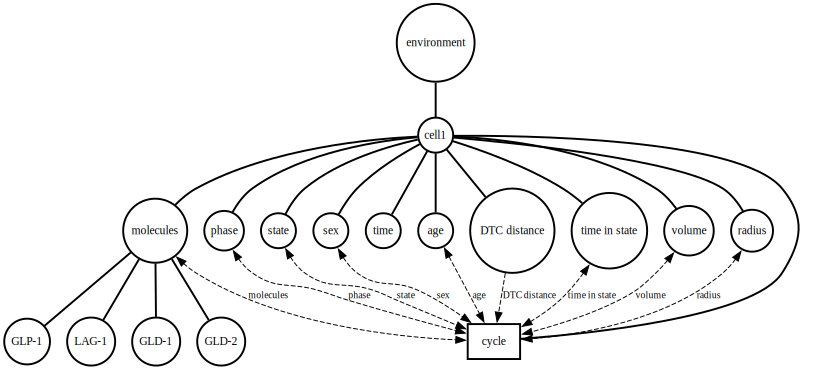

In [194]:
doc1 = {
    'environment': {
        'cell1': {
            'cycle': {
                '_type': 'process',
                'address': 'local:cell_cycle',
                'config': {
                    # 'interval': 60.0,  #TODO
                    'G1duration': 5.0,
                    'G2duration': 5.0,
                    'Sduration': 5.0,
                    'Mduration': 5.0,
                },
                'inputs': {
                    'molecules': ['molecules'],
                    'DTC distance': ['DTC distance'],
                    'time in state': ['time in state'],
                    'age': ['age'],
                    'state': ['state'],
                    'phase': ['phase'],
                    'sex': ['sex'],
                    'volume': ['volume'],
                    'radius': ['radius'],
                },
                'outputs': {
                    'molecules': ['molecules'],
                    'time in state': ['time in state'],
                    'age': ['age'],
                    'state': ['state'],
                    'phase': ['phase'],
                    'sex': ['sex'],
                    'volume': ['volume'],
                    'radius': ['radius'],
                }
            },
        
            'phase': 'S',
            'state': 'mitosis',
            'sex': 'precursor',
            'molecules': {
                'GLP-1': 'unbound',
                'LAG-1': 'inactive',
                'GLD-1': 'active',
                'GLD-2': 'active',
            },
            'time': 0.0,
            'age': 0.0
        }
    }
}

plot_bigraph(doc1)

# run simulation

In [192]:
# build the simulation
sim1 = Composite(
    config={'state': doc1},
    core=core
)

# run the simulation
sim1.run(1000)

my current state: mitosis, phase: S, time in state 0.0, age 0.0
my current state: mitosis, phase: S, time in state 1.0, age 1.0
my current state: mitosis, phase: S, time in state 2.0, age 2.0
my current state: mitosis, phase: S, time in state 3.0, age 3.0
my current state: mitosis, phase: S, time in state 4.0, age 4.0
my current state: mitosis, phase: S, time in state 5.0, age 5.0
my current state: mitosis, phase: S, time in state 6.0, age 6.0
my current state: mitosis, phase: G2, time in state 0.0, age 7.0
my current state: mitosis, phase: G2, time in state 1.0, age 8.0
my current state: mitosis, phase: G2, time in state 2.0, age 9.0
my current state: mitosis, phase: G2, time in state 3.0, age 10.0
my current state: mitosis, phase: G2, time in state 4.0, age 11.0
my current state: mitosis, phase: G2, time in state 5.0, age 12.0
my current state: mitosis, phase: G2, time in state 6.0, age 13.0
my current state: mitosis, phase: M, time in state 0.0, age 14.0
my current state: mitosis, p

Exception: ProphaseMeiosisI is not in the enum, options are: ['G2', 'M', 'G1', 'S', 'MeioticS', 'prophase']

In [ ]:
# get the results 
results = gather_emitter_results(sim1)
results

# multicellular

# integrated